In [1]:

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.impute import KNNImputer

from sklearn.preprocessing import (
    LabelEncoder,
    OneHotEncoder,
    OrdinalEncoder,
    StandardScaler,
    MinMaxScaler
)

from sklearn.compose import ColumnTransformer

from scipy.stats import zscore
from scipy.stats.mstats import winsorize

import sqlite3

In [2]:

# =========================================================
# 2. LOAD DATA
# =========================================================

# ---------------- CSV ----------------
csv_df = pd.read_csv("users - users.csv.csv")

print("\nCSV DATA LOADED SUCCESSFULLY")
print(csv_df.head())



CSV DATA LOADED SUCCESSFULLY
  user_id           name  age gender       city registration_date
0   U0001  Vihaan Sharma   35  Other     Jaipur        2022-09-08
1   U0002      Sai Reddy   30  Other  Hyderabad        2023-11-24
2   U0003   Aarohi Gupta   37  Other     Indore        2022-02-02
3   U0004    Aarav Gupta   44   Male    Kolkata        2023-06-02
4   U0005    Sara Sharma   30  Other    Chennai        2024-01-04


In [3]:
# ---------------- JSON ----------------
json_df = pd.read_json("sales.json")

print("\nJSON DATA LOADED SUCCESSFULLY")
print(json_df.head())


JSON DATA LOADED SUCCESSFULLY
  transaction_id user_id product_id  amount payment_type       date
0        T000001   U0024       P015   67.67       Wallet 2023-02-12
1        T000002   U0196       P044   76.44          UPI 2023-03-24
2        T000003   U0196       P049  104.57   Debit Card 2025-08-21
3        T000004   U0133       P042  102.75  Net Banking 2024-07-23
4        T000005   U0047       P038   23.89  Net Banking 2025-10-04


In [4]:

# ---------------- SQL ----------------
import sqlite3

conn = sqlite3.connect("inventory.db")

sql_df = pd.read_sql("SELECT * FROM products", conn)

print(sql_df.head())
print("\nSQL DATA LOADED SUCCESSFULLY")

  product_id product_name category    price  stock
0       P001  Product_001  Grocery   264.89    371
1       P002  Product_002  Grocery   605.91    150
2       P003  Product_003   Beauty  3027.98    127
3       P004  Product_004     Toys  2600.12    229
4       P005  Product_005    Books  1178.99     18

SQL DATA LOADED SUCCESSFULLY


In [5]:
# =========================================================
# MAIN DATASET
# =========================================================

df = csv_df.copy()

print("\nMAIN DATASET")
print(df.head())


MAIN DATASET
  user_id           name  age gender       city registration_date
0   U0001  Vihaan Sharma   35  Other     Jaipur        2022-09-08
1   U0002      Sai Reddy   30  Other  Hyderabad        2023-11-24
2   U0003   Aarohi Gupta   37  Other     Indore        2022-02-02
3   U0004    Aarav Gupta   44   Male    Kolkata        2023-06-02
4   U0005    Sara Sharma   30  Other    Chennai        2024-01-04


In [6]:
# =========================================================
# TASK 3 : DATA UNDERSTANDING
# =========================================================

print("\n================ TOP 5 RECORDS ================")
print(df.head())


print("\n================ BOTTOM 5 RECORDS ================")
print(df.tail())


print("\n================ SHAPE ================")
print(df.shape)


print("\n================ COLUMN NAMES ================")
print(df.columns)


print("\n================ DATA TYPES ================")
print(df.dtypes)


print("\n================ DATA INFO ================")
print(df.info())


print("\n================ SUMMARY STATISTICS ================")
print(df.describe())


print("\n================ MISSING VALUES ================")
print(df.isnull().sum())


print("\n================ DUPLICATES ================")
print(df.duplicated().sum())


================ TOP 5 RECORDS ================
  user_id           name  age gender       city registration_date
0   U0001  Vihaan Sharma   35  Other     Jaipur        2022-09-08
1   U0002      Sai Reddy   30  Other  Hyderabad        2023-11-24
2   U0003   Aarohi Gupta   37  Other     Indore        2022-02-02
3   U0004    Aarav Gupta   44   Male    Kolkata        2023-06-02
4   U0005    Sara Sharma   30  Other    Chennai        2024-01-04

================ BOTTOM 5 RECORDS ================
    user_id            name  age  gender           city registration_date
195   U0196  Kabir Kulkarni   35   Other          Patna        2024-08-01
196   U0197       Kabir Roy   24    Male          Thane        2023-12-07
197   U0198      Kabir Bose   33  Female  Visakhapatnam        2023-07-07
198   U0199       Meera Roy   32    Male      Ghaziabad        2022-02-10
199   U0200      Kiara Nair   22   Other         Jaipur        2022-01-27

================ SHAPE ================
(200, 6)

========

In [7]:
# =========================================================
# TASK 4 : DATA CLEANING
# =========================================================

# ---------------- REMOVE DUPLICATES ----------------

df.drop_duplicates(inplace=True)

print("\nDuplicate Removed")
print(df.duplicated().sum())


Duplicate Removed
0


In [8]:
# =========================================================
# FIX INVALID VALUES
# =========================================================

# Example:
# Negative price -> positive price
if 'price' in df.columns:

    print("\nNEGATIVE PRICE COUNT BEFORE FIX")
    print((df['price'] < 0).sum())

    df['price'] = df['price'].abs()

    print("\nNEGATIVE PRICE COUNT AFTER FIX")
    print((df['price'] < 0).sum())

In [9]:
# =========================================================
# DATE FORMAT FIXING
# =========================================================

if 'date' in df.columns:

    df['date'] = pd.to_datetime(df['date'], errors='coerce')

    print("\nDATE FORMAT FIXED")
    print(df['date'].head())

In [10]:

# =========================================================
# MISSING VALUES BEFORE
# =========================================================

print("\nMISSING VALUES BEFORE CLEANING")
print(df.isnull().sum())


MISSING VALUES BEFORE CLEANING
user_id              0
name                 0
age                  0
gender               0
city                 0
registration_date    0
dtype: int64


In [11]:
# =========================================================
# SIMPLE IMPUTER FOR NUMERICAL DATA
# =========================================================

num_cols = df.select_dtypes(include=np.number).columns

print("\nNUMERICAL COLUMNS")
print(num_cols)


mean_imputer = SimpleImputer(strategy='mean')

df[num_cols] = mean_imputer.fit_transform(df[num_cols])

print("\nNUMERICAL MISSING VALUES FILLED")


NUMERICAL COLUMNS
Index(['age'], dtype='object')

NUMERICAL MISSING VALUES FILLED


In [12]:


# =========================================================
# SIMPLE IMPUTER FOR CATEGORICAL DATA
# =========================================================

cat_cols = df.select_dtypes(include='object').columns

print("\nCATEGORICAL COLUMNS")
print(cat_cols)


freq_imputer = SimpleImputer(strategy='most_frequent')

df[cat_cols] = freq_imputer.fit_transform(df[cat_cols])

print("\nCATEGORICAL MISSING VALUES FILLED")


CATEGORICAL COLUMNS
Index(['user_id', 'name', 'gender', 'city', 'registration_date'], dtype='object')

CATEGORICAL MISSING VALUES FILLED


In [13]:
# =========================================================
# KNN IMPUTER
# =========================================================

knn_cols = df.select_dtypes(include=np.number).columns

knn_imputer = KNNImputer(n_neighbors=3)

df[knn_cols] = knn_imputer.fit_transform(df[knn_cols])

print("\nKNN IMPUTATION APPLIED")


print("\nMISSING VALUES AFTER CLEANING")
print(df.isnull().sum())


KNN IMPUTATION APPLIED

MISSING VALUES AFTER CLEANING
user_id              0
name                 0
age                  0
gender               0
city                 0
registration_date    0
dtype: int64


In [14]:

# =========================================================
# TASK 5 : OUTLIER HANDLING
# =========================================================

numeric_columns = df.select_dtypes(include=np.number).columns

In [15]:
# =========================================================
# Z-SCORE METHOD
# =========================================================

z_scores = np.abs(zscore(df[numeric_columns]))

print("\nZ-SCORE VALUES")
print(z_scores)


threshold = 3

outliers = (z_scores > threshold)

print("\nOUTLIER COUNT USING Z-SCORE")
print(outliers.sum())


Z-SCORE VALUES
[[0.51566639]
 [0.17372718]
 [0.79142381]
 [1.7565748 ]
 [0.17372718]
 [0.17372718]
 [1.7565748 ]
 [0.92930252]
 [0.4494846 ]
 [0.6535451 ]
 [0.4494846 ]
 [0.4494846 ]
 [0.23990896]
 [1.82827173]
 [1.82827173]
 [0.58736332]
 [1.13887817]
 [0.37778767]
 [1.00099945]
 [1.55251431]
 [1.61869609]
 [0.17372718]
 [0.10203025]
 [1.55251431]
 [0.58736332]
 [0.10203025]
 [1.27675688]
 [0.51566639]
 [0.58736332]
 [0.31160589]
 [0.58736332]
 [2.03233223]
 [0.03584847]
 [1.13887817]
 [0.92930252]
 [1.27675688]
 [0.23990896]
 [1.82827173]
 [1.41463559]
 [0.23990896]
 [0.79142381]
 [0.23990896]
 [0.03584847]
 [0.31160589]
 [1.55251431]
 [0.72524203]
 [0.4494846 ]
 [1.20505995]
 [0.37778767]
 [1.82827173]
 [0.37778767]
 [0.4494846 ]
 [0.72524203]
 [0.6535451 ]
 [1.20505995]
 [1.06718124]
 [0.86312074]
 [0.31160589]
 [0.37778767]
 [1.06718124]
 [0.4494846 ]
 [0.17372718]
 [1.13887817]
 [1.27675688]
 [0.92930252]
 [1.48081738]
 [0.03584847]
 [1.20505995]
 [0.37778767]
 [0.72524203]
 [0.

In [16]:
# =========================================================
# REMOVE OUTLIERS USING Z-SCORE
# =========================================================

df_zscore = df[(z_scores < threshold).all(axis=1)]

print("\nSHAPE BEFORE Z-SCORE")
print(df.shape)

print("\nSHAPE AFTER Z-SCORE")
print(df_zscore.shape)


SHAPE BEFORE Z-SCORE
(200, 6)

SHAPE AFTER Z-SCORE
(200, 6)


In [17]:
# =========================================================
# IQR METHOD
# =========================================================

Q1 = df[numeric_columns].quantile(0.25)
Q3 = df[numeric_columns].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR


df_iqr = df[
    ~((df[numeric_columns] < lower_bound) |
      (df[numeric_columns] > upper_bound)).any(axis=1)
]

print("\nSHAPE BEFORE IQR")
print(df.shape)

print("\nSHAPE AFTER IQR")
print(df_iqr.shape)


SHAPE BEFORE IQR
(200, 6)

SHAPE AFTER IQR
(198, 6)


In [18]:
# =========================================================
# COMPARISON
# =========================================================

print("\nCOMPARISON")

print("Original Shape :", df.shape)
print("After Z-Score :", df_zscore.shape)
print("After IQR :", df_iqr.shape)


COMPARISON
Original Shape : (200, 6)
After Z-Score : (200, 6)
After IQR : (198, 6)


In [19]:
# =========================================================
# WINSORIZATION
# =========================================================

for col in numeric_columns:

    df[col] = winsorize(df[col], limits=[0.05, 0.05])

print("\nWINSORIZATION APPLIED")


WINSORIZATION APPLIED


In [20]:
# =========================================================
# TASK 6 : DATA TRANSFORMATION
# =========================================================

# =========================================================
# DATE FEATURE EXTRACTION
# =========================================================

if 'date' in df.columns:

    df['day'] = df['date'].dt.day
    df['month'] = df['date'].dt.month
    df['year'] = df['date'].dt.year

    print("\nDATE FEATURES CREATED")

    print(df[['date', 'day', 'month', 'year']].head())

In [21]:

# =========================================================
# LABEL ENCODING
# =========================================================

binary_cols = []

for col in df.select_dtypes(include='object').columns:

    if df[col].nunique() == 2:
        binary_cols.append(col)

print("\nBINARY COLUMNS")
print(binary_cols)


le = LabelEncoder()

for col in binary_cols:

    df[col] = le.fit_transform(df[col])

print("\nLABEL ENCODING APPLIED")


BINARY COLUMNS
[]

LABEL ENCODING APPLIED


In [22]:
# =========================================================
# ONE HOT ENCODING
# =========================================================

nominal_cols = []

for col in df.select_dtypes(include='object').columns:

    if df[col].nunique() > 2:
        nominal_cols.append(col)

print("\nNOMINAL COLUMNS")
print(nominal_cols)


df = pd.get_dummies(df, columns=nominal_cols)

print("\nONE HOT ENCODING APPLIED")

print(df.head())


NOMINAL COLUMNS
['user_id', 'name', 'gender', 'city', 'registration_date']

ONE HOT ENCODING APPLIED
    age  user_id_U0001  user_id_U0002  user_id_U0003  user_id_U0004  \
0  35.0           True          False          False          False   
1  30.0          False           True          False          False   
2  37.0          False          False           True          False   
3  44.0          False          False          False           True   
4  30.0          False          False          False          False   

   user_id_U0005  user_id_U0006  user_id_U0007  user_id_U0008  user_id_U0009  \
0          False          False          False          False          False   
1          False          False          False          False          False   
2          False          False          False          False          False   
3          False          False          False          False          False   
4           True          False          False          False          

In [23]:
# =========================================================
# ORDINAL ENCODING
# =========================================================

# Example Column:
# Low < Medium < High

if 'income_level' in df.columns:

    order = [['Low', 'Medium', 'High']]

    oe = OrdinalEncoder(categories=order)

    df[['income_level']] = oe.fit_transform(df[['income_level']])

    print("\nORDINAL ENCODING APPLIED")

    print(df[['income_level']].head())

In [24]:


# =========================================================
# BINNING
# =========================================================

if 'income' in df.columns:

    df['income_group'] = pd.cut(
        df['income'],
        bins=3,
        labels=['Low', 'Medium', 'High']
    )

    print("\nBINNING APPLIED")

    print(df[['income', 'income_group']].head())

In [25]:
# =========================================================
# LOG TRANSFORMATION
# =========================================================

if 'income' in df.columns:

    df['income_log'] = np.log1p(df['income'])

    print("\nLOG TRANSFORMATION APPLIED")

    print(df[['income', 'income_log']].head())

In [26]:

# =========================================================
# SQUARE ROOT TRANSFORMATION
# =========================================================

if 'income' in df.columns:

    df['income_sqrt'] = np.sqrt(df['income'])

    print("\nSQUARE ROOT TRANSFORMATION APPLIED")

    print(df[['income', 'income_sqrt']].head())

In [27]:
# =========================================================
# TASK 7 : FEATURE SCALING
# =========================================================

scale_cols = df.select_dtypes(include=np.number).columns

print("\nCOLUMNS FOR SCALING")
print(scale_cols)


COLUMNS FOR SCALING
Index(['age'], dtype='object')


In [28]:


# =========================================================
# STANDARD SCALER
# =========================================================

standard_scaler = StandardScaler()

df_standard = pd.DataFrame(
    standard_scaler.fit_transform(df[scale_cols]),
    columns=scale_cols
)

print("\nSTANDARD SCALING APPLIED")

print(df_standard.head())


STANDARD SCALING APPLIED
        age
0  0.563756
1 -0.176081
2  0.859690
3  1.895462
4 -0.176081


In [29]:
# =========================================================
# MINMAX SCALER
# =========================================================

minmax_scaler = MinMaxScaler()

df_minmax = pd.DataFrame(
    minmax_scaler.fit_transform(df[scale_cols]),
    columns=scale_cols
)

print("\nMINMAX SCALING APPLIED")

print(df_minmax.head())


MINMAX SCALING APPLIED
        age
0  0.625000
1  0.416667
2  0.708333
3  1.000000
4  0.416667


In [30]:

# =========================================================
# SCALING COMPARISON
# =========================================================

print("\nSTANDARD SCALER SUMMARY")
print(df_standard.describe())


print("\nMINMAX SCALER SUMMARY")
print(df_minmax.describe())


STANDARD SCALER SUMMARY
                age
count  2.000000e+02
mean  -1.953993e-16
std    1.002509e+00
min   -1.655755e+00
25%   -7.679506e-01
50%    4.586988e-02
75%    6.007475e-01
max    1.895462e+00

MINMAX SCALER SUMMARY
              age
count  200.000000
mean     0.466250
std      0.282300
min      0.000000
25%      0.250000
50%      0.479167
75%      0.635417
max      1.000000


In [31]:

# =========================================================
# COLUMN TRANSFORMER
# =========================================================

transformer = ColumnTransformer(
    transformers=[
        ('scaler', StandardScaler(), scale_cols)
    ],
    remainder='passthrough'
)

transformed_data = transformer.fit_transform(df)

print("\nCOLUMN TRANSFORMER APPLIED")

print(transformed_data)


COLUMN TRANSFORMER APPLIED
[[ 0.56375568  1.          0.         ...  0.          0.
   0.        ]
 [-0.17608117  0.          1.         ...  0.          0.
   0.        ]
 [ 0.85969041  0.          0.         ...  0.          0.
   0.        ]
 ...
 [ 0.26782094  0.          0.         ...  0.          0.
   0.        ]
 [ 0.11985357  0.          0.         ...  0.          0.
   0.        ]
 [-1.35982012  0.          0.         ...  0.          0.
   0.        ]]


In [32]:
# =========================================================
# TASK 8 : FEATURE CONSTRUCTION
# =========================================================

# =========================================================
# AVERAGE MONTHLY SPEND
# =========================================================

if 'total_spend' in df.columns:

    df['avg_monthly_spend'] = df['total_spend'] / 12

    print("\nAVERAGE MONTHLY SPEND CREATED")

    print(df[['total_spend', 'avg_monthly_spend']].head())

In [33]:

# =========================================================
# PURCHASE FREQUENCY
# =========================================================

if 'purchase_count' in df.columns:

    df['purchase_frequency'] = df['purchase_count'] / 30

    print("\nPURCHASE FREQUENCY CREATED")

    print(df[['purchase_count', 'purchase_frequency']].head())

In [34]:

# =========================================================
# DAYS SINCE LAST PURCHASE
# =========================================================

if 'date' in df.columns:

    current_date = pd.to_datetime('today')

    df['days_since_last_purchase'] = (
        current_date - df['date']
    ).dt.days

    print("\nDAYS SINCE LAST PURCHASE CREATED")

    print(df[['date', 'days_since_last_purchase']].head())

In [35]:

# =========================================================
# CATEGORY WISE TOTAL EXPENDITURE
# =========================================================

if 'category' in df.columns and 'price' in df.columns:

    category_expense = df.groupby('category')['price'].sum()

    print("\nCATEGORY WISE TOTAL EXPENDITURE")

    print(category_expense)

In [36]:


# =========================================================
# FINAL DATASET PREPARATION
# =========================================================

print("\n================ FINAL DATASET ================")

print(df.head())


print("\n================ FINAL SHAPE ================")

print(df.shape)


print("\n================ FINAL INFO ================")

print(df.info())


================ FINAL DATASET ================
    age  user_id_U0001  user_id_U0002  user_id_U0003  user_id_U0004  \
0  35.0           True          False          False          False   
1  30.0          False           True          False          False   
2  37.0          False          False           True          False   
3  44.0          False          False          False           True   
4  30.0          False          False          False          False   

   user_id_U0005  user_id_U0006  user_id_U0007  user_id_U0008  user_id_U0009  \
0          False          False          False          False          False   
1          False          False          False          False          False   
2          False          False          False          False          False   
3          False          False          False          False          False   
4           True          False          False          False          False   

   ...  registration_date_2024-08-04  regis

In [37]:

# =========================================================
# REPORT GENERATION
# =========================================================

print("\n================ FINAL REPORT ================")

print("Records After Cleaning :", df.shape[0])

print("Total Features :", df.shape[1])

print("\nMissing Values Summary")
print(df.isnull().sum())

print("\nOutlier Handling Completed")


================ FINAL REPORT ================
Records After Cleaning : 200
Total Features : 572

Missing Values Summary
age                             0
user_id_U0001                   0
user_id_U0002                   0
user_id_U0003                   0
user_id_U0004                   0
                               ..
registration_date_2024-08-29    0
registration_date_2024-08-30    0
registration_date_2024-09-10    0
registration_date_2024-09-21    0
registration_date_2024-09-27    0
Length: 572, dtype: int64

Outlier Handling Completed


In [38]:
# =========================================================
# SAVE FINAL CLEAN DATASET
# =========================================================

df.to_csv("final_cleaned_dataset.csv", index=False)

print("\nFINAL CLEAN DATASET SAVED SUCCESSFULLY")


FINAL CLEAN DATASET SAVED SUCCESSFULLY


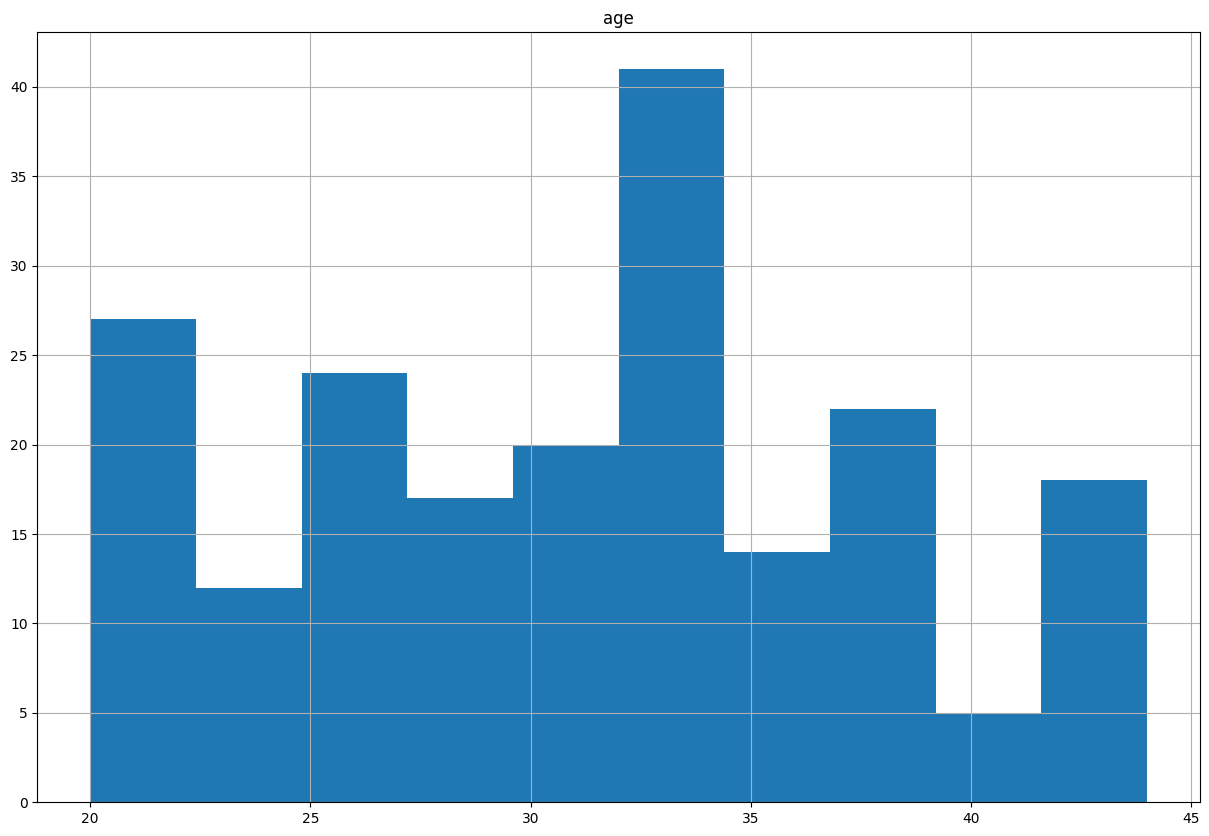

In [39]:

# =========================================================
# VISUALIZATION
# =========================================================

# =========================================================
# HISTOGRAM
# =========================================================

df.hist(figsize=(15,10))

plt.show()

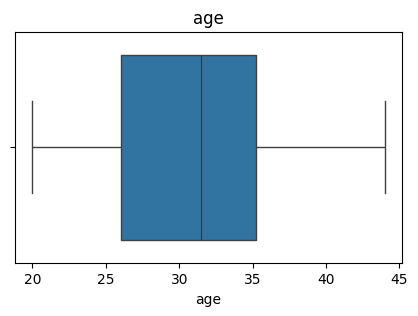

In [40]:

# =========================================================
# BOXPLOT
# =========================================================

for col in numeric_columns:

    plt.figure(figsize=(5,3))

    sns.boxplot(x=df[col])

    plt.title(col)

    plt.show()

In [ ]:

# =========================================================
# HEATMAP
# =========================================================

plt.figure(figsize=(12,8))

sns.heatmap(df.corr(numeric_only=True), annot=True)

plt.show()

In [41]:

# =========================================================
# PROJECT COMPLETED
# =========================================================

print("\n======================================")
print("PROJECT COMPLETED SUCCESSFULLY")
print("ALL 8 TASKS COMPLETED")
print("DATA PREPROCESSING COMPLETED")
print("FEATURE ENGINEERING COMPLETED")
print("======================================")


PROJECT COMPLETED SUCCESSFULLY
ALL 8 TASKS COMPLETED
DATA PREPROCESSING COMPLETED
FEATURE ENGINEERING COMPLETED
